# Import Libraries

In [ ]:
# Data Handling
import pandas as pd

# Text Processing
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# TensorFlow / Keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt
import seaborn as sns

import pickle

In [20]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

In [21]:
train_df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [22]:
test_df.head()

,id,comment_text
0,00001cee341fdb12,Yo bitch Ja Rule is more succesful then you'll...
1,0000247867823ef7,== From RfC == \n\n The title is fine as it is...
2,00013b17ad220c46,""" \n\n == Sources == \n\n * Zawe Ashton on Lap..."
3,00017563c3f7919a,":If you have a look back at the source, the in..."
4,00017695ad8997eb,I don't anonymously edit articles at all.


In [23]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   id             159571 non-null  str  
 1   comment_text   159571 non-null  str  
 2   toxic          159571 non-null  int64
 3   severe_toxic   159571 non-null  int64
 4   obscene        159571 non-null  int64
 5   threat         159571 non-null  int64
 6   insult         159571 non-null  int64
 7   identity_hate  159571 non-null  int64
dtypes: int64(6), str(2)
memory usage: 72.2 MB


In [24]:
test_df.shape

(153164, 2)

In [25]:
train_df.shape

(159571, 8)

# Check Missing Values

In [26]:
train_df.isnull().sum()


id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

In [27]:
test_df.isnull().sum()

id              0
comment_text    0
dtype: int64

# Remove Duplicates

In [28]:
train_df = train_df.drop_duplicates()

# Download NLTK Resources

In [29]:
nltk.download('punkt')
nltk.download('punkt_tab')    # Required for newer NLTK versions
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\harin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\harin\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\harin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\harin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\harin\AppData\Roaming\nltk_data...


True

# Text Cleaning

In [30]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    words = word_tokenize(text)

    words = [word for word in words if word not in stop_words]

    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

# Apply Cleaning

In [31]:
train_df["clean_comment"] = train_df["comment_text"].apply(clean_text)



In [32]:
test_df["clean_comment"] = test_df["comment_text"].apply(clean_text)

# Define Features and Target

In [33]:
X = train_df["clean_comment"]

y = train_df["toxic"]

# Train Test Split

In [34]:
X_train, X_valid, y_train, y_valid = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42

)

# Tokenization

In [35]:
tokenizer = Tokenizer(num_words=20000)

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)

X_valid_seq = tokenizer.texts_to_sequences(X_valid)

X_test_seq = tokenizer.texts_to_sequences(test_df["clean_comment"])

# Padding

In [36]:
max_length = 150

X_train_pad = pad_sequences(

    X_train_seq,

    maxlen=max_length,

    padding="post"

)

X_valid_pad = pad_sequences(

    X_valid_seq,

    maxlen=max_length,

    padding="post"

)

X_test_pad = pad_sequences(

    X_test_seq,

    maxlen=max_length,

    padding="post"

)

# Build LSTM Model

In [37]:
model = Sequential()

model.add(

    Embedding(

        input_dim=20000,

        output_dim=128,

        input_length=max_length

    )

)

model.add(

    LSTM(64)

)

model.add(

    Dropout(0.5)

)

model.add(

    Dense(1, activation="sigmoid")

)

c:\Users\harin\anaconda3\envs\toxicity_env\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


# Compile Model

In [38]:
model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=["accuracy"]

)

# Train Model

In [39]:
early_stop = EarlyStopping(

    monitor="val_loss",

    patience=3,

    restore_best_weights=True

)

history = model.fit(

    X_train_pad,

    y_train,

    validation_data=(X_valid_pad, y_valid),

    epochs=10,

    batch_size=64,

    callbacks=[early_stop]

)

Epoch 1/10
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 221s 109ms/step - accuracy: 0.9044 - loss: 0.3206 - val_accuracy: 0.9051 - val_loss: 0.3129
Epoch 2/10
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 230s 115ms/step - accuracy: 0.9057 - loss: 0.3144 - val_accuracy: 0.9051 - val_loss: 0.3126
Epoch 3/10
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 277s 139ms/step - accuracy: 0.9034 - loss: 0.3128 - val_accuracy: 0.9048 - val_loss: 0.3132
Epoch 4/10
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 259s 130ms/step - accuracy: 0.9078 - loss: 0.2582 - val_accuracy: 0.9050 - val_loss: 0.1908
Epoch 5/10
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 258s 129ms/step - accuracy: 0.9382 - loss: 0.1652 - val_accuracy: 0.9051 - val_loss: 0.1712
Epoch 6/10
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 283s 142ms/step - accuracy: 0.9528 - loss: 0.1296 - val_accuracy: 0.9573 - val_loss: 0.1326
Epoch 7/10
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 279s 140ms/step - accuracy: 0.9667 - loss: 0.0966 - val_accuracy: 0.9594 - val_loss: 0.1278
Epoch 8/10
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 284s 143ms/step - ac

# Evaluate Model

In [40]:
loss, accuracy = model.evaluate(

    X_valid_pad,

    y_valid

)

print("Accuracy :", accuracy)

998/998 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.9594 - loss: 0.1278
Accuracy : 0.9594234824180603


# Predictions

In [41]:
predictions = model.predict(X_valid_pad)

predictions = (predictions > 0.5).astype(int)

998/998 ━━━━━━━━━━━━━━━━━━━━ 22s 21ms/step


# Classification Report

In [42]:
print(

    classification_report(

        y_valid,

        predictions

    )

)

              precision    recall  f1-score   support

           0       0.97      0.98      0.98     28859
           1       0.83      0.73      0.77      3056

    accuracy                           0.96     31915
   macro avg       0.90      0.85      0.88     31915
weighted avg       0.96      0.96      0.96     31915



# Confusion Matrix

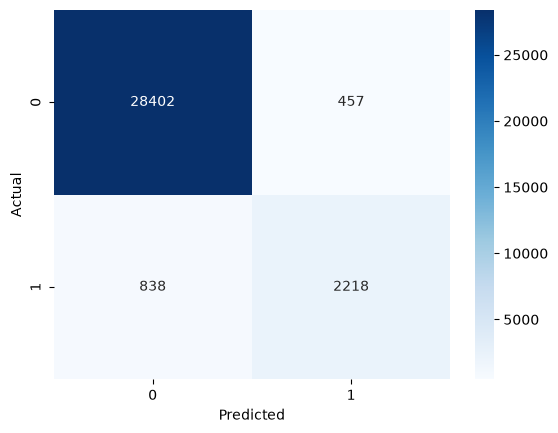

In [43]:
cm = confusion_matrix(

    y_valid,

    predictions

)

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# Accuracy Graph

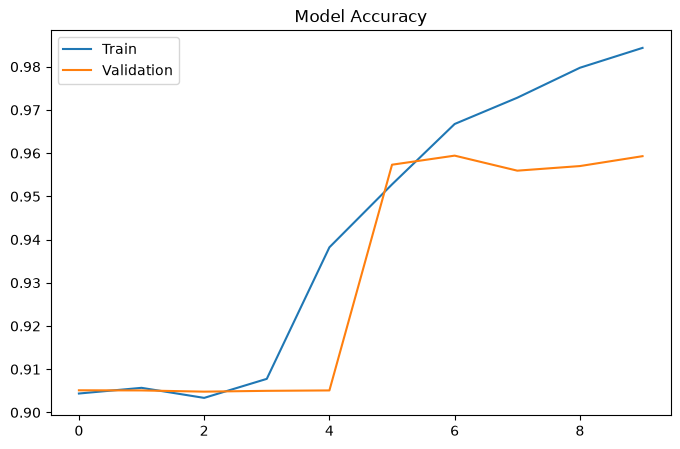

In [44]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"])

plt.plot(history.history["val_accuracy"])

plt.legend(["Train","Validation"])

plt.title("Model Accuracy")

plt.show()

# Loss Graph

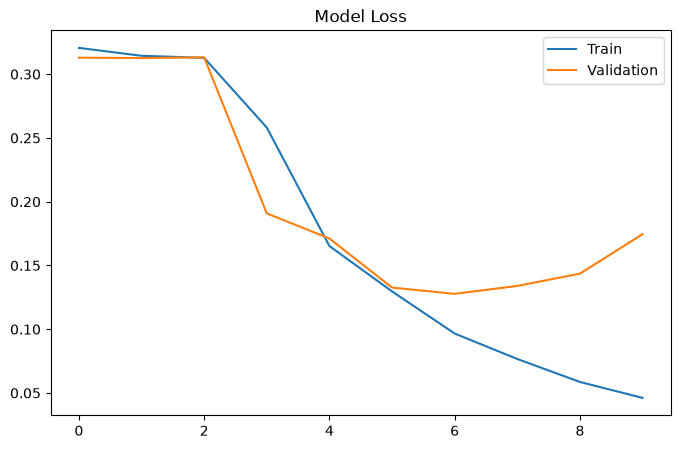

In [45]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"])

plt.plot(history.history["val_loss"])

plt.legend(["Train","Validation"])

plt.title("Model Loss")

plt.show()

# Save Model

In [46]:
model.save("tox_model.h5")

# Save Tokenizer

In [47]:
with open("tokenizer.pkl","wb") as file:

    pickle.dump(tokenizer,file)

# Load Tokenizer

In [49]:
with open("tokenizer.pkl","rb") as file:

    tokenizer = pickle.load(file)

# Predict New Comment

In [55]:
comment = "You are such an idiot"

comment = clean_text(comment)

sequence = tokenizer.texts_to_sequences([comment])

sequence = pad_sequences(

    sequence,

    maxlen=max_length,

    padding="post"

)

prediction = model.predict(sequence)

if prediction > 0.5:

    print("Toxic Comment")

else:

    print("Non-Toxic Comment")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
Toxic Comment


In [56]:
model.save("toxicity_model.keras")

In [57]:
import pickle

with open("tokenizer.pkl", "wb") as file:
    pickle.dump(tokenizer, file)

In [58]:
from tensorflow.keras.models import load_model

loaded_model = load_model("toxicity_model.keras")

c:\Users\harin\anaconda3\envs\toxicity_env\Lib\site-packages\keras\src\saving\saving_lib.py:843: UserWarning: Skipping variable loading for optimizer 'adam', because it has 14 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [59]:
import pickle

with open("tokenizer.pkl", "rb") as file:
    loaded_tokenizer = pickle.load(file)